# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**请填写**  
第5天专题（A/B/C/D/E）：**请填写**

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "24012408"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 24012408
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [2]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,总体流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券使用次数,1.72
6,平均返现,177.22
7,平均App使用时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,流失率,平均订单数,平均优惠券使用次数,平均返现,平均满意度,平均距上次下单天数
0,1-6个月,1642,0.26,2.68,1.74,164.87,3.09,4.05
1,13-24个月,1467,0.06,3.70,2.02,204.92,3.09,5.32
2,7-12个月,1584,0.10,2.75,1.60,163.31,2.99,4.38
3,两年以上老用户,429,0.00,3.55,1.94,222.34,3.05,5.26
4,新用户,508,0.54,1.89,0.96,142.44,3.18,2.88


,TenureGroup,PreferredLoginDevice,用户数,流失人数,流失率,平均订单数,样本提示
0,1-6个月,Computer,495,149,0.30,2.87,可观察
1,1-6个月,Mobile Phone,1147,276,0.24,2.60,可观察
2,13-24个月,Computer,409,21,0.05,3.54,可观察
3,13-24个月,Mobile Phone,1058,74,0.07,3.77,可观察
4,7-12个月,Computer,484,61,0.13,2.75,可观察


检查点1A通过：输入文件有效


In [3]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同生命周期阶段用户的流失率存在怎样的差异？",
    "behavior_scatter": "用户平均订单数量与平均满意度之间是否存在关联？",
    "ordered_line": "随着用户生命周期延长，平均订单数呈现怎样的变化趋势？",
    "composition_chart": "平台用户在不同生命周期阶段的分布构成如何？",
}

chart_reasons = {
    "category_bar": "分类柱状图适合对比不同类别间的数值差异，可直观展示各生命周期组流失率的高低对比。",
    "behavior_scatter": "散点图适合探索两个连续变量间的相关性，能揭示订单行为与满意度之间的潜在关系。",
    "ordered_line": "折线图适合展示有序序列上的趋势变化，能清晰呈现用户行为指标随生命周期的演变规律。",
    "composition_chart": "构成图适合展示各部分占整体的比例关系，帮助理解平台用户结构的分布特征。",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [4]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "TenureGroup"
category_summary = (
    df.groupby(category_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
      .reset_index()
)

tenure_order = ["新用户", "1-6个月", "7-12个月", "13-24个月", "两年以上老用户"]
category_summary["TenureGroup"] = pd.Categorical(
    category_summary["TenureGroup"], categories=tenure_order, ordered=True
)
category_summary = category_summary.sort_values("TenureGroup").reset_index(drop=True)

# 参考结构，不是答案：
# category_summary = (
#     df.groupby(category_field, observed=True)
#       .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
#       .reset_index()
# )

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)


,TenureGroup,用户数,流失率
0,新用户,508,0.54
1,1-6个月,1642,0.26
2,7-12个月,1584,0.10
3,13-24个月,1467,0.06
4,两年以上老用户,429,0.00


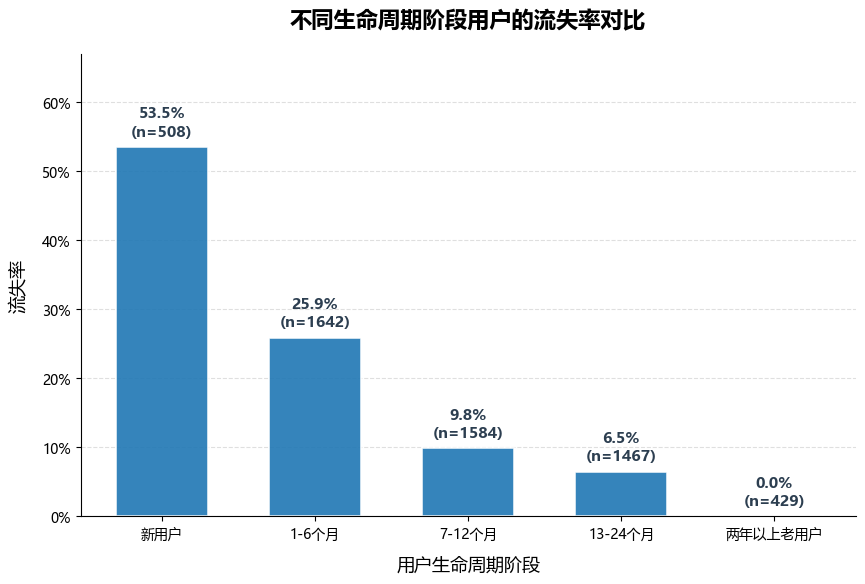

已输出： output\day06_visualization\01_category_bar.png


In [5]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
bars = ax_bar.bar(
    category_summary["TenureGroup"].astype(str),
    category_summary["流失率"],
    edgecolor="white",
    linewidth=1.2,
    width=0.6,
    alpha=0.9,
)

for bar, row in zip(bars, category_summary.itertuples()):
    height = bar.get_height()
    label_text = f"{height:.1%}\n(n={row.用户数})"
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        label_text,
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="#2C3E50",
    )

ax_bar.set_title("不同生命周期阶段用户的流失率对比", fontsize=16, fontweight="bold", pad=20)
ax_bar.set_xlabel("用户生命周期阶段", fontsize=13, labelpad=10)
ax_bar.set_ylabel("流失率", fontsize=13, labelpad=10)
ax_bar.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax_bar.set_ylim(0, max(category_summary["流失率"]) * 1.25)
ax_bar.yaxis.grid(True, linestyle="--", alpha=0.4)
ax_bar.set_axisbelow(True)
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：用户流失率随生命周期延长呈显著递减趋势。
- 证据：新用户流失率为 53.54%（n=508），1-6个月用户降至 25.88%（n=1642），7-12个月用户为 9.85%（n=1584），13-24个月用户为 6.48%（n=1467），两年以上老用户流失率为 0%（n=429），呈下降趋势。
- 边界：该图不能证明生命周期延长是流失率下降的主要原因。


## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


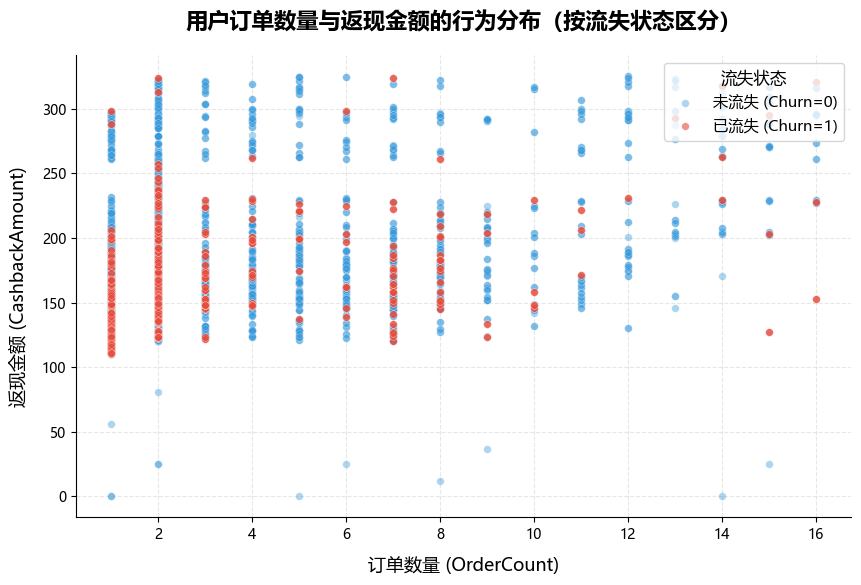

已输出： output\day06_visualization\02_behavior_scatter.png


In [6]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 在此按Churn分组绘制散点图，并补充标题、坐标轴和图例
churn_0 = df[df["Churn"] == 0]
churn_1 = df[df["Churn"] == 1]

ax_scatter.scatter(
    churn_0[x_field],
    churn_0[y_field],
    c="#3498DB",
    alpha=0.4,
    s=30,
    edgecolors="white",
    linewidth=0.3,
    label="未流失 (Churn=0)",
)
ax_scatter.scatter(
    churn_1[x_field],
    churn_1[y_field],
    c="#E74C3C",
    alpha=0.6,
    s=30,
    edgecolors="white",
    linewidth=0.3,
    label="已流失 (Churn=1)",
)

ax_scatter.set_title("用户订单数量与返现金额的行为分布（按流失状态区分）", fontsize=16, fontweight="bold", pad=20)
ax_scatter.set_xlabel("订单数量 (OrderCount)", fontsize=13, labelpad=10)
ax_scatter.set_ylabel("返现金额 (CashbackAmount)", fontsize=13, labelpad=10)
ax_scatter.legend(title="流失状态", loc="upper right", fontsize=11, title_fontsize=12)
ax_scatter.grid(True, linestyle="--", alpha=0.3)
ax_scatter.set_axisbelow(True)
ax_scatter.spines["top"].set_visible(False)
ax_scatter.spines["right"].set_visible(False)

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))


### 散点图结论

- 观察：订单数量与返现金额呈正相关关系。
- 证据：整体数据点沿左下向右上方向分布，表明订单数越高的用户通常返现金额也越高；已流失用户（红色点）高度集中在 OrderCount ≤ 5 且 CashbackAmount ≤ 200 的区间，而未流失用户（蓝色点）则更多分布在 OrderCount > 5 或 CashbackAmount > 200 的区域；图中存在少量异常点，如订单数仅 1–2 笔但返现金额接近 300 的用户，可能对应高客单价品类消费。
- 边界：订单数量与返现金额的正相关可能由平台"订单越多返现越多"的活动规则直接驱动，而非用户自发行为模式。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [7]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]

# TODO：准备有序绘图数据
ordered_field = "TenureGroup"
ordered_summary = (
    df.groupby(ordered_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 平均订单数=("OrderCount", "mean"))
      .reset_index()
)
ordered_summary[ordered_field] = pd.Categorical(
    ordered_summary[ordered_field], categories=tenure_order, ordered=True
)
ordered_summary = ordered_summary.sort_values(ordered_field).reset_index(drop=True)

assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)


,TenureGroup,用户数,平均订单数
0,新用户,508,1.89
1,1-6个月,1642,2.68
2,7-12个月,1584,2.75
3,13-24个月,1467,3.70
4,两年以上老用户,429,3.55


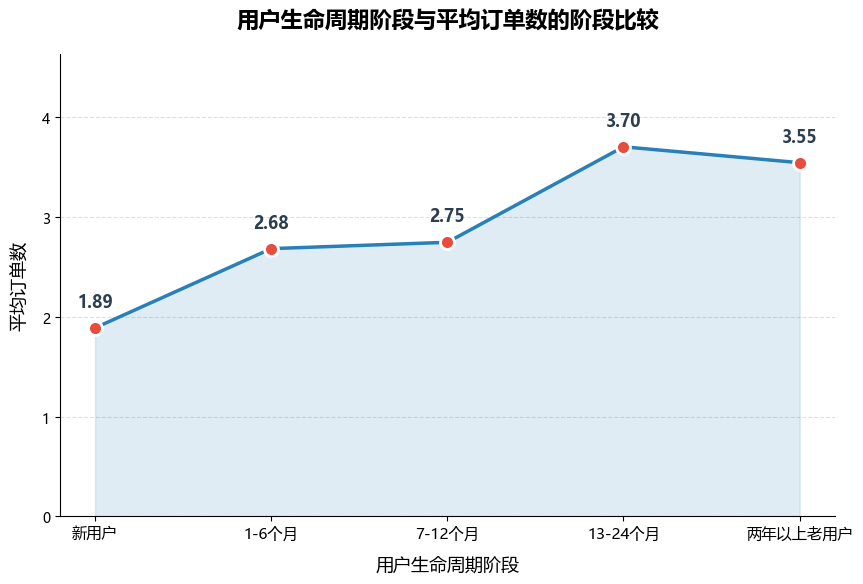

已输出： output\day06_visualization\03_ordered_line.png


In [8]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
x_positions = range(len(ordered_summary))
x_labels = ordered_summary[ordered_field].astype(str)
# 绘制折线
ax_line.plot(
    x_positions,
    ordered_summary["平均订单数"],
    marker="o",
    markersize=10,
    markerfacecolor="#E74C3C",
    markeredgecolor="white",
    markeredgewidth=2,
    linewidth=2.5,
    color="#2980B9",
    linestyle="-",
    zorder=3,
)
# 标注每个点的数值
for i, row in ordered_summary.iterrows():
    ax_line.annotate(
        f"{row['平均订单数']:.2f}",
        (i, row["平均订单数"]),
        textcoords="offset points",
        xytext=(0, 15),
        ha="center",
        fontsize=12,
        fontweight="bold",
        color="#2C3E50",
    )

# 填充区域增强视觉效果
ax_line.fill_between(
    x_positions,
    ordered_summary["平均订单数"],
    alpha=0.15,
    color="#2980B9",
)

ax_line.set_title("用户生命周期阶段与平均订单数的阶段比较", fontsize=16, fontweight="bold", pad=20)
ax_line.set_xlabel("用户生命周期阶段", fontsize=13, labelpad=10)
ax_line.set_ylabel("平均订单数", fontsize=13, labelpad=10)
ax_line.set_xticks(x_positions)
ax_line.set_xticklabels(x_labels, fontsize=11)
ax_line.set_ylim(0, max(ordered_summary["平均订单数"]) * 1.25)
ax_line.yaxis.grid(True, linestyle="--", alpha=0.4)
ax_line.set_axisbelow(True)
ax_line.spines["top"].set_visible(False)
ax_line.spines["right"].set_visible(False)

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))


### 折线图结论

- 观察：用户平均订单数随生命周期延长总体呈上升趋势，在13-24个月阶段达到峰值，但两年以上老用户略有回落。
- 证据：新用户平均订单数最低，为 1.89（n=508）；1-6个月用户上升至 2.68（n=1642）；7-12个月用户为 2.75（n=1584）；13-24个月用户达到峰值 3.70（n=1467）；两年以上老用户略降至 3.55（n=429）。
- 边界：该图仅展示不同生命周期阶段的横向阶段比较，不代表平台随月度、年度推移的历史时间趋势。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [9]:
# TODO：选择构成字段并准备汇总表
composition_field = "TenureGroup"

tenure_order = ["新用户", "1-6个月", "7-12个月", "13-24个月", "两年以上老用户"]

composition_summary = (
    df.groupby(composition_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"))
      .reset_index()
)

# 按业务生命周期顺序排列
composition_summary[composition_field] = pd.Categorical(
    composition_summary[composition_field], categories=tenure_order, ordered=True
)
composition_summary = composition_summary.sort_values(composition_field).reset_index(drop=True)

# 计算占比
composition_summary["占比"] = composition_summary["用户数"] / composition_summary["用户数"].sum()

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)


,TenureGroup,用户数,占比
0,新用户,508,0.09
1,1-6个月,1642,0.29
2,7-12个月,1584,0.28
3,13-24个月,1467,0.26
4,两年以上老用户,429,0.08


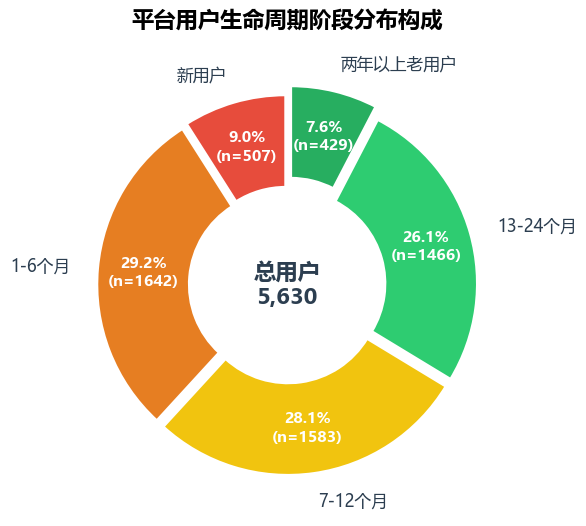

已输出： output\day06_visualization\04_composition_chart.png


In [10]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# 在此编写绘图和优化代码
labels = composition_summary[composition_field].astype(str)
sizes = composition_summary["占比"]
users = composition_summary["用户数"]

colors = ["#E74C3C", "#E67E22", "#F1C40F", "#2ECC71", "#27AE60"]
explode = (0.03, 0.03, 0.03, 0.03, 0.08)

wedges, texts, autotexts = ax_composition.pie(
    sizes,
    labels=labels,
    autopct=lambda pct: f"{pct:.1f}%\n(n={int(pct/100.*users.sum())})",
    startangle=90,
    colors=colors,
    explode=explode,
    wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=12, color="#2C3E50"),
    pctdistance=0.75,
    labeldistance=1.15,
)

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight("bold")
    autotext.set_color("white")

ax_composition.text(0, 0, f"总用户\n{users.sum():,}", ha="center", va="center",
                    fontsize=16, fontweight="bold", color="#2C3E50")
ax_composition.set_title("平台用户生命周期阶段分布构成", fontsize=16, fontweight="bold", pad=20)

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))


### 构成图结论

- 观察：1-6个月和7-12个月的中期用户是平台的主体，而新用户和两年以上老用户占比较低。
- 证据：1-6个月用户占比最高，为 29.16%（n=1642）；7-12个月用户占 28.14%（n=1584）；13-24个月用户占 26.06%（n=1467）；新用户占 9.02%（n=508）；两年以上老用户仅占 7.62%（n=429）。中期用户（1-24个月）合计占比超过 83%。
- 边界：该图适合直观展示各部分占整体的比例关系，帮助理解平台用户结构的构成特征；但不适合精确比较各类别之间的绝对数值差异。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [11]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


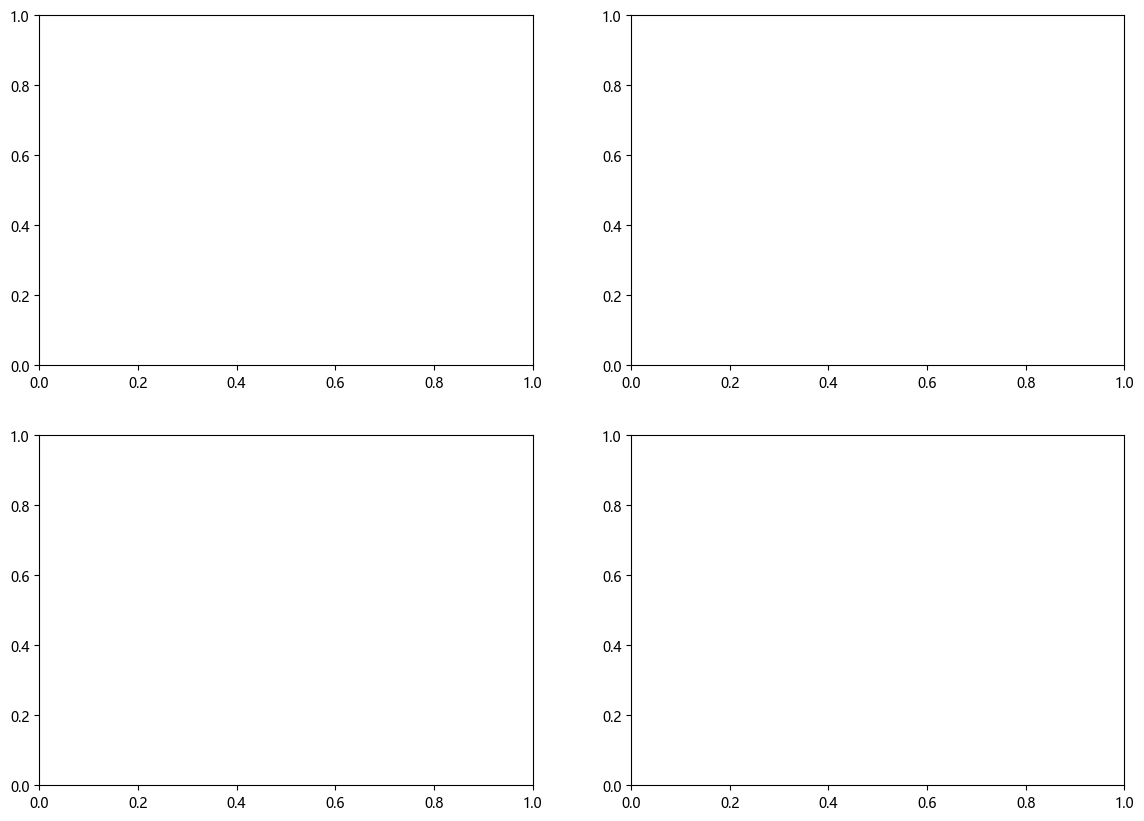

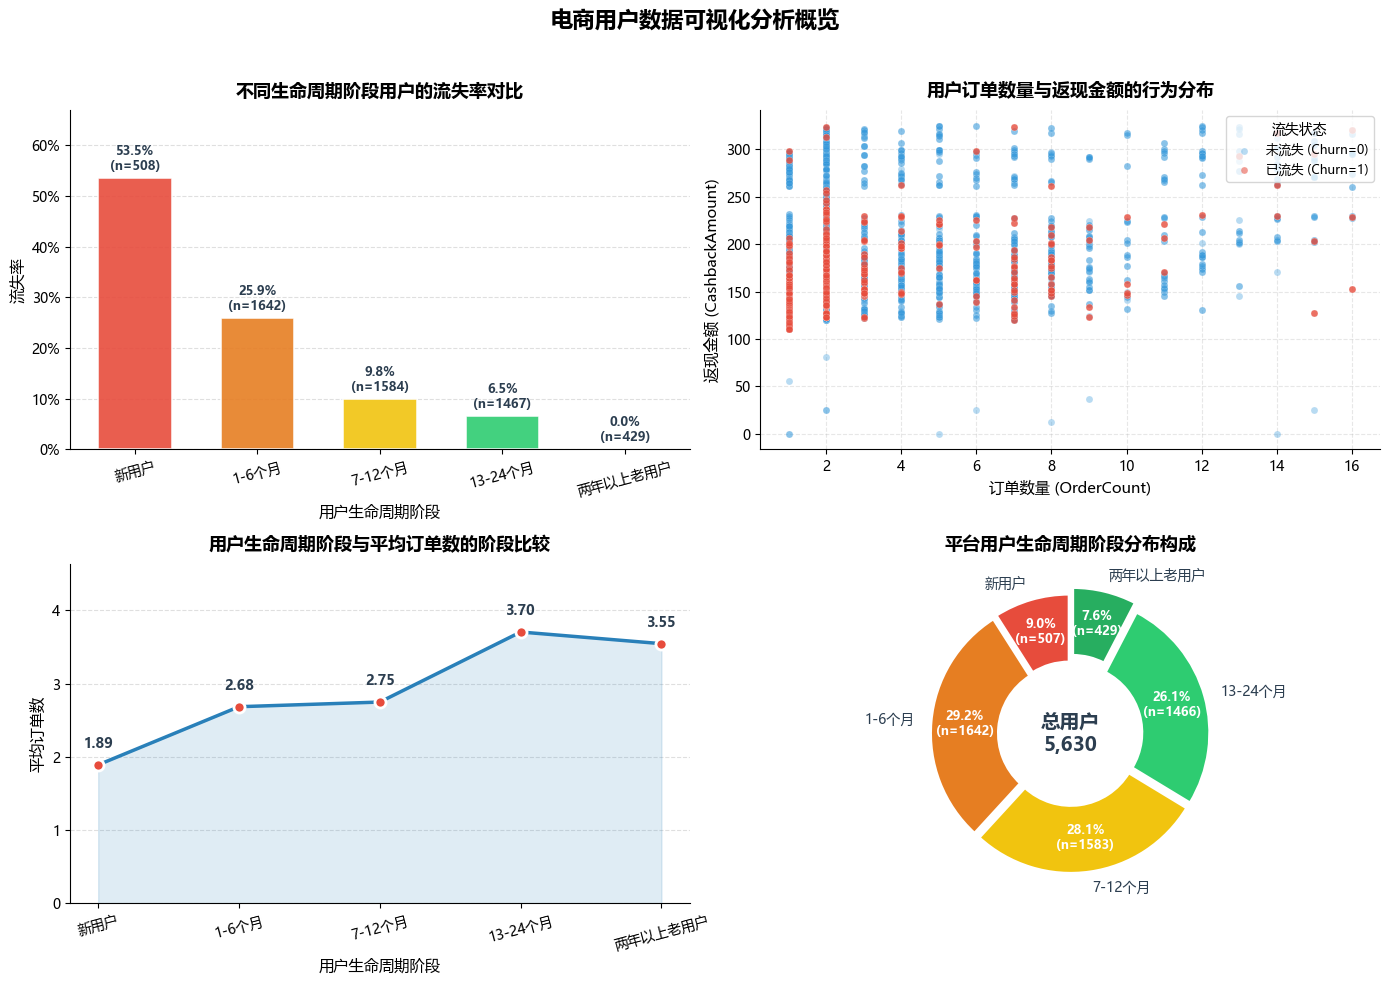

已输出： output\day06_visualization\day06_visualization_summary.png


In [12]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO：分别在axes[0,0]、axes[0,1]、axes[1,0]、axes[1,1]绘制4张核心图
colors_tenure = ["#E74C3C", "#E67E22", "#F1C40F", "#2ECC71", "#27AE60"]
color_churn_yes = "#E74C3C"
color_churn_no = "#3498DB"
color_line = "#2980B9"

# 统一字体大小
TITLE_SIZE = 13
LABEL_SIZE = 11
TICK_SIZE = 10

# 生命周期顺序
tenure_order = ["新用户", "1-6个月", "7-12个月", "13-24个月", "两年以上老用户"]

# ============================================================
# 子图1：柱状图（axes[0,0]）
# ============================================================
category_field = "TenureGroup"
category_summary = (
    df.groupby(category_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
      .reset_index()
)
category_summary["TenureGroup"] = pd.Categorical(
    category_summary["TenureGroup"], categories=tenure_order, ordered=True
)
category_summary = category_summary.sort_values("TenureGroup").reset_index(drop=True)

# ============================================================
# 子图2：散点图数据（axes[0,1]）
# ============================================================
x_field = "OrderCount"
y_field = "CashbackAmount"
churn_0 = df[df["Churn"] == 0]
churn_1 = df[df["Churn"] == 1]

# ============================================================
# 子图3：折线图数据（axes[1,0]）
# ============================================================
ordered_field = "TenureGroup"
ordered_summary = (
    df.groupby(ordered_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 平均订单数=("OrderCount", "mean"))
      .reset_index()
)
ordered_summary[ordered_field] = pd.Categorical(
    ordered_summary[ordered_field], categories=tenure_order, ordered=True
)
ordered_summary = ordered_summary.sort_values(ordered_field).reset_index(drop=True)

# ============================================================
# 子图4：构成图数据（axes[1,1]）
# ============================================================
composition_field = "TenureGroup"
composition_summary = (
    df.groupby(composition_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"))
      .reset_index()
)
composition_summary[composition_field] = pd.Categorical(
    composition_summary[composition_field], categories=tenure_order, ordered=True
)
composition_summary = composition_summary.sort_values(composition_field).reset_index(drop=True)
composition_summary["占比"] = composition_summary["用户数"] / composition_summary["用户数"].sum()

# ============================================================
# 创建 2×2 综合图
# ============================================================
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---------- 子图1：柱状图 ----------
ax = axes[0, 0]
bars = ax.bar(
    category_summary["TenureGroup"].astype(str),
    category_summary["流失率"],
    color=colors_tenure,
    edgecolor="white",
    linewidth=1.2,
    width=0.6,
    alpha=0.9,
)
for bar, row in zip(bars, category_summary.itertuples()):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.1%}\n(n={row.用户数})",
        ha="center", va="bottom", fontsize=9, fontweight="bold", color="#2C3E50",
    )
ax.set_title("不同生命周期阶段用户的流失率对比", fontsize=TITLE_SIZE, fontweight="bold", pad=10)
ax.set_xlabel("用户生命周期阶段", fontsize=LABEL_SIZE)
ax.set_ylabel("流失率", fontsize=LABEL_SIZE)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.set_ylim(0, max(category_summary["流失率"]) * 1.25)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="x", labelsize=TICK_SIZE, rotation=15)
ax.tick_params(axis="y", labelsize=TICK_SIZE)

# ---------- 子图2：散点图 ----------
ax = axes[0, 1]
ax.scatter(
    churn_0[x_field], churn_0[y_field],
    c=color_churn_no, alpha=0.35, s=25, edgecolors="white", linewidth=0.2,
    label="未流失 (Churn=0)",
)
ax.scatter(
    churn_1[x_field], churn_1[y_field],
    c=color_churn_yes, alpha=0.55, s=25, edgecolors="white", linewidth=0.2,
    label="已流失 (Churn=1)",
)
ax.set_title("用户订单数量与返现金额的行为分布", fontsize=TITLE_SIZE, fontweight="bold", pad=10)
ax.set_xlabel("订单数量 (OrderCount)", fontsize=LABEL_SIZE)
ax.set_ylabel("返现金额 (CashbackAmount)", fontsize=LABEL_SIZE)
ax.legend(title="流失状态", loc="upper right", fontsize=9, title_fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=TICK_SIZE)

# ---------- 子图3：折线图 ----------
ax = axes[1, 0]
x_positions = range(len(ordered_summary))
ax.plot(
    x_positions, ordered_summary["平均订单数"],
    marker="o", markersize=8, markerfacecolor="#E74C3C", markeredgecolor="white",
    markeredgewidth=2, linewidth=2.5, color=color_line, linestyle="-", zorder=3,
)
for i, row in ordered_summary.iterrows():
    ax.annotate(
        f"{row['平均订单数']:.2f}",
        (i, row["平均订单数"]),
        textcoords="offset points", xytext=(0, 12),
        ha="center", fontsize=10, fontweight="bold", color="#2C3E50",
    )
ax.fill_between(x_positions, ordered_summary["平均订单数"], alpha=0.15, color=color_line)
ax.set_title("用户生命周期阶段与平均订单数的阶段比较", fontsize=TITLE_SIZE, fontweight="bold", pad=10)
ax.set_xlabel("用户生命周期阶段", fontsize=LABEL_SIZE)
ax.set_ylabel("平均订单数", fontsize=LABEL_SIZE)
ax.set_xticks(x_positions)
ax.set_xticklabels(ordered_summary[ordered_field].astype(str), fontsize=TICK_SIZE, rotation=15)
ax.set_ylim(0, max(ordered_summary["平均订单数"]) * 1.25)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=TICK_SIZE)

# ---------- 子图4：环形图 ----------
ax = axes[1, 1]
labels = composition_summary[composition_field].astype(str)
sizes = composition_summary["占比"]
users = composition_summary["用户数"]
explode = (0.03, 0.03, 0.03, 0.03, 0.08)

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct=lambda pct: f"{pct:.1f}%\n(n={int(pct/100.*users.sum())})",
    startangle=90,
    colors=colors_tenure,
    explode=explode,
    wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=10, color="#2C3E50"),
    pctdistance=0.75,
    labeldistance=1.12,
)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight("bold")
    autotext.set_color("white")

ax.text(0, 0, f"总用户\n{users.sum():,}", ha="center", va="center",
        fontsize=14, fontweight="bold", color="#2C3E50")
ax.set_title("平台用户生命周期阶段分布构成", fontsize=TITLE_SIZE, fontweight="bold", pad=10)


fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))


## 综合发现与局限

1. 综合发现1：新用户是平台流失风险最高且订单活跃度最低的群体，新用户转化是平台最紧迫的运营痛点。

   证据：柱状图显示新用户流失率高达 53.54%（n=508），为所有生命周期阶段最高；折线图显示新用户平均订单数仅 1.89，亦为各阶段最低。两者叠加表明，新用户不仅极易流失，且尚未形成稳定的下单习惯。
2. 综合发现2：平台用户结构呈"中间大、两头小"的橄榄型分布，中期用户向长期忠诚用户的沉淀存在明显瓶颈。

   证据：构成图显示1-6个月、7-12个月、13-24个月三类中期用户合计占比超过 83%（n=4,693），是平台的绝对主体；但两年以上老用户仅占 7.62%（n=429）。结合折线图，13-24个月用户平均订单数达到峰值 3.70，但老用户反而略降至 3.55，说明即使进入成熟期的用户也未必能持续沉淀为超高频忠诚用户。
3. 综合发现3：已流失用户的行为特征高度集中，呈现"低订单、低返现"的明显聚集模式，可作为早期预警指标。

   证据：散点图显示，已流失用户（红色点）高度聚集在 OrderCount ≤ 5 且 CashbackAmount ≤ 200 的左下角区域；而未流失用户（蓝色点）则广泛分布于中高订单数和高返现金额区间。这一行为分异特征可用于构建流失预警模型。
4. 数据或方法局限：
   首先，CashbackAmount 是平台返还给用户的优惠金额，并非用户实际消费金额、销售额或 GMV，因此不能直接用作用户经济价值或平台收入的代理指标。其次，当前数据为截面快照，无法建立时间序列上的因果关系——例如，低订单数与流失之间的关联可能是"低活跃导致流失"，也可能是"用户决定流失前停止下单"的结果，存在反向因果的可能。此外，两年以上老用户样本量较小（n=429），其 0% 流失率的估计可能存在抽样波动。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [13]:
# TODO：填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
    {"chart_id": "01", "file_name": "01_category_bar.png", "business_question": "不同生命周期阶段用户的流失率存在怎样的差异？", "chart_type": "bar", "key_finding": "新用户流失率高达53.54%，随生命周期延长流失率持续下降，1-6个月用户为25.88%，7-12个月为9.85%，13-24个月为6.48%，两年以上老用户流失率为0%。", "limitation": "不能证明生命周期延长是流失率下降的直接因果原因（可能存在选择偏差）；两年以上老用户样本量较小(n=429)，0%流失率可能受样本规模限制。"},
    {"chart_id": "02", "file_name": "02_behavior_scatter.png", "business_question": "用户订单数量与返现金额之间是否存在关联，流失用户的行为分布有何特征？", "chart_type": "scatter", "key_finding": "已流失用户高度聚集在低订单数(OrderCount≤5)和低返现金额(CashbackAmount≤200)的左下角区域；未流失用户分布范围更广，覆盖中高订单数和高返现金额区间。", "limitation": "CashbackAmount是返现金额而非销售额或GMV；相关关系不等于因果关系，低订单/低返现可能是流失原因也可能是用户即将流失前停止下单的结果，存在反向因果。"},
    {"chart_id": "03", "file_name": "03_ordered_line.png", "business_question": "随着用户生命周期延长，平均订单数呈现怎样的变化趋势？", "chart_type": "line", "key_finding": "平均订单数随生命周期延长总体上升，新用户1.89笔，1-6个月2.68笔，7-12个月2.75笔，13-24个月达峰值3.70笔，两年以上老用户略降至3.55笔。", "limitation": "这是有序阶段比较而非月度/年度时间序列趋势；阶段间差异可能受用户自我选择效应影响（留存用户本身活跃度更高），不能推断当前新用户必然达到老用户订单水平。"},
    {"chart_id": "04", "file_name": "04_composition_chart.png", "business_question": "平台用户在不同生命周期阶段的分布构成如何？", "chart_type": "pie_or_bar", "key_finding": "平台用户呈橄榄型分布，1-6个月(29.16%, n=1642)、7-12个月(28.14%, n=1584)和13-24个月(26.06%, n=1467)三类中期用户合计占比超83%。", "limitation": "不适合精确比较各类别绝对数值差异（人眼对角度/面积敏感度低于柱长），也不适合展示随时间变化的趋势或各类别间相关性。"},
    {"chart_id": "05", "file_name": "day06_visualization_summary.png", "business_question": "整体概览", "chart_type": "dashboard", "key_finding": "新用户是流失风险最高且订单活跃度最低的群体；中期用户是平台主体但向长期忠诚用户沉淀存在瓶颈；已流失用户呈现'低订单、低返现'的明显聚集模式。", "limitation": "CashbackAmount非销售额/GMV；截面数据无法建立时间序列因果关系；老用户样本量较小(n=429)；综合图单图信息密度高，子图细节不如独立大图清晰。"},
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同生命周期阶段用户的流失率存在怎样的差异？,bar,新用户流失率高达53.54%，随生命周期延长流失率持续下降，1-6个月用户为25.88%，7...,不能证明生命周期延长是流失率下降的直接因果原因（可能存在选择偏差）；两年以上老用户样本量较小...
1,02,02_behavior_scatter.png,用户订单数量与返现金额之间是否存在关联，流失用户的行为分布有何特征？,scatter,已流失用户高度聚集在低订单数(OrderCount≤5)和低返现金额(CashbackAmo...,CashbackAmount是返现金额而非销售额或GMV；相关关系不等于因果关系，低订单/低...
2,03,03_ordered_line.png,随着用户生命周期延长，平均订单数呈现怎样的变化趋势？,line,平均订单数随生命周期延长总体上升，新用户1.89笔，1-6个月2.68笔，7-12个月2.7...,这是有序阶段比较而非月度/年度时间序列趋势；阶段间差异可能受用户自我选择效应影响（留存用户本...
3,04,04_composition_chart.png,平台用户在不同生命周期阶段的分布构成如何？,pie_or_bar,"平台用户呈橄榄型分布，1-6个月(29.16%, n=1642)、7-12个月(28.14%...",不适合精确比较各类别绝对数值差异（人眼对角度/面积敏感度低于柱长），也不适合展示随时间变化的...
4,05,day06_visualization_summary.png,整体概览,dashboard,新用户是流失风险最高且订单活跃度最低的群体；中期用户是平台主体但向长期忠诚用户沉淀存在瓶颈；...,CashbackAmount非销售额/GMV；截面数据无法建立时间序列因果关系；老用户样本量...


In [14]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
